# Smart Event Analytics Agent
### Agentic AI Practical – Technical Club Performance Analysis

**Problem:** Analyze all technical events conducted last semester and identify which clubs performed the best.

The notebook demonstrates an agentic workflow: understand the reporting goal → collect data → validate/missing-data handling → calculate deterministic metrics → compare clubs → explain rankings → generate a report.

The design follows the supplied Agentic AI notes: agents are goal-oriented, reason over information, plan actions, use tools, execute workflows, and use feedback. Unit II also emphasizes goal decomposition, planning, ReAct, autonomous workflow execution, uncertainty handling, and dynamic replanning. 

## 1. Agent architecture

```text
User Request
    ↓
Agent Controller / Goal Understanding
    ↓
Task Planner
    ↓
Data Tools ──→ events / registrations / attendance / feedback
    ↓
Validation + Missing Data Handler
    ↓
Deterministic Metric Engine
    ↓
Club Comparison + Utility Score
    ↓
Ranking Explanation
    ↓
Final Report
```

**Why this is agentic:** the controller decomposes the goal, selects tools, checks observations, handles incomplete data, and continues until the reporting objective is completed.

In [3]:
# 2. Imports and setup
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, Any, List

pd.set_option('display.max_columns', None)
print('Environment ready.')

Environment ready.


In [4]:
# 3. Synthetic semester data
# Replace these DataFrames with CSV/database/API data in a real deployment.

events = pd.DataFrame([
    ['E01','AI Club','AI Hackathon',180,150,4.5],
    ['E02','Coding Club','Competitive Coding Bootcamp',140,120,4.2],
    ['E03','Robotics Club','Robotics Workshop',110,92,4.6],
    ['E04','AI Club','GenAI Seminar',160,132,4.7],
    ['E05','Coding Club','DSA Contest',200,165,4.4],
    ['E06','Robotics Club','Drone Technology Talk',90,72,4.3],
    ['E07','Cyber Club','Ethical Hacking Workshop',130,108,4.5],
    ['E08','AI Club','Computer Vision Workshop',125,100,4.4],
    ['E09','Cyber Club','CTF Challenge',170,145,4.7],
    ['E10','Robotics Club','Automation Challenge',150,121,4.5],
], columns=['event_id','club','event_name','registrations','attendance','feedback_score'])

# Separate registration/attendance/feedback tables mimic real institutional systems.
registrations = events[['event_id','club','registrations']].copy()
attendance = events[['event_id','attendance']].copy()
feedback = events[['event_id','feedback_score']].copy()

print('Events:', len(events))
display(events)

Events: 10


,event_id,club,event_name,registrations,attendance,feedback_score
0,E01,AI Club,AI Hackathon,180,150,4.5
1,E02,Coding Club,Competitive Coding Bootcamp,140,120,4.2
2,E03,Robotics Club,Robotics Workshop,110,92,4.6
3,E04,AI Club,GenAI Seminar,160,132,4.7
4,E05,Coding Club,DSA Contest,200,165,4.4
5,E06,Robotics Club,Drone Technology Talk,90,72,4.3
6,E07,Cyber Club,Ethical Hacking Workshop,130,108,4.5
7,E08,AI Club,Computer Vision Workshop,125,100,4.4
8,E09,Cyber Club,CTF Challenge,170,145,4.7
9,E10,Robotics Club,Automation Challenge,150,121,4.5


In [5]:
# 4. Tool layer – the agent can call these tools instead of directly manipulating data.

def get_event_data():
    return events.copy()

def get_registration_data():
    return registrations.copy()

def get_attendance_data():
    return attendance.copy()

def get_feedback_data():
    return feedback.copy()

def validate_data(df):
    report = {
        'rows': len(df),
        'missing_by_column': df.isna().sum().to_dict(),
        'duplicate_rows': int(df.duplicated().sum())
    }
    return report

TOOLS = {
    'events': get_event_data,
    'registrations': get_registration_data,
    'attendance': get_attendance_data,
    'feedback': get_feedback_data,
}

for name, tool in TOOLS.items():
    print(name, validate_data(tool()))

events {'rows': 10, 'missing_by_column': {'event_id': 0, 'club': 0, 'event_name': 0, 'registrations': 0, 'attendance': 0, 'feedback_score': 0}, 'duplicate_rows': 0}
registrations {'rows': 10, 'missing_by_column': {'event_id': 0, 'club': 0, 'registrations': 0}, 'duplicate_rows': 0}
attendance {'rows': 10, 'missing_by_column': {'event_id': 0, 'attendance': 0}, 'duplicate_rows': 0}
feedback {'rows': 10, 'missing_by_column': {'event_id': 0, 'feedback_score': 0}, 'duplicate_rows': 0}


## 5. Goal decomposition

The user request is decomposed into manageable tasks, matching the Unit II idea of breaking a complex objective into smaller tasks:

1. Identify the reporting scope.
2. Collect event, registration, attendance and feedback observations.
3. Validate the observations and identify missing data.
4. Calculate club-level metrics.
5. Apply a transparent utility function.
6. Rank clubs and explain the result.
7. Generate the final report.

In [6]:
# 6. Deterministic metric engine

def calculate_metrics(event_df):
    df = event_df.copy()
    df['attendance_rate'] = np.where(
        df['registrations'] > 0,
        df['attendance'] / df['registrations'] * 100,
        np.nan
    )

    summary = df.groupby('club').agg(
        events=('event_id','count'),
        registrations=('registrations','sum'),
        attendance=('attendance','sum'),
        avg_feedback=('feedback_score','mean'),
        avg_attendance_rate=('attendance_rate','mean')
    ).reset_index()

    summary['attendance_rate'] = summary['attendance'] / summary['registrations'] * 100
    return summary

metrics = calculate_metrics(events)
display(metrics.round(2))

,club,events,registrations,attendance,avg_feedback,avg_attendance_rate,attendance_rate
0,AI Club,3,465,382,4.53,81.94,82.15
1,Coding Club,2,340,285,4.30,84.11,83.82
2,Cyber Club,2,300,253,4.60,84.19,84.33
3,Robotics Club,3,350,285,4.47,81.43,81.43


In [7]:
# 7. Utility-based ranking
# Transparent utility: quality + participation + scale.
# Feedback is normalized to 0–100 because it is measured on a 1–5 scale.

def add_utility_score(summary):
    s = summary.copy()
    s['feedback_pct'] = s['avg_feedback'] / 5 * 100
    s['participation_pct'] = s['attendance_rate'].clip(0,100)

    # Log scaling prevents very large event counts from dominating.
    s['reach_pct'] = (np.log1p(s['attendance']) / np.log1p(s['attendance']).max()) * 100

    # Weights can be changed by the institution.
    s['utility_score'] = (
        0.45 * s['feedback_pct'] +
        0.35 * s['participation_pct'] +
        0.20 * s['reach_pct']
    )
    s['rank'] = s['utility_score'].rank(method='min', ascending=False).astype(int)
    return s.sort_values(['rank','club'])

ranking = add_utility_score(metrics)
display(ranking[['rank','club','events','registrations','attendance',
                  'attendance_rate','avg_feedback','utility_score']].round(2))

,rank,club,events,registrations,attendance,attendance_rate,avg_feedback,utility_score
0,1,AI Club,3,465,382,82.15,4.53,89.55
2,2,Cyber Club,2,300,253,84.33,4.60,89.54
3,3,Robotics Club,3,350,285,81.43,4.47,87.72
1,4,Coding Club,2,340,285,83.82,4.30,87.06


In [8]:
# 8. Missing-data handling
def handle_missing(df):
    issues = []
    out = df.copy()
    for col in ['registrations','attendance','feedback_score']:
        if col in out.columns and out[col].isna().any():
            count = int(out[col].isna().sum())
            issues.append(f'{col}: {count} missing value(s)')
            # Conservative rule: do not invent raw observations.
            # Keep missing values and let aggregation ignore unavailable feedback.
    if not issues:
        issues.append('No missing values detected in the supplied dataset.')
    return out, issues

clean_events, missing_issues = handle_missing(events)
print('\n'.join('• ' + x for x in missing_issues))

• No missing values detected in the supplied dataset.


In [9]:
# 9. Agent controller: plan → tools → observe → evaluate → report

from dataclasses import dataclass, field
from typing import Dict, Any, List

@dataclass
class SmartEventAnalyticsAgent:
    goal: str
    state: Dict[str, Any] = field(default_factory=dict)
    trace: List[str] = field(default_factory=list)

    def understand_goal(self):
        self.state['scope'] = 'last semester technical events'
        self.state['objective'] = 'rank clubs using participation, reach and feedback quality'
        self.trace.append('UNDERSTAND: reporting request converted into measurable objectives')

    def plan(self):
        self.state['plan'] = [
            'collect_events', 'collect_registrations', 'collect_attendance',
            'collect_feedback', 'validate', 'calculate_metrics',
            'rank', 'explain', 'report'
        ]
        self.trace.append('PLAN: created multi-step execution plan')

    def execute_tools(self):
        self.state['events'] = TOOLS['events']()
        self.state['registrations'] = TOOLS['registrations']()
        self.state['attendance'] = TOOLS['attendance']()
        self.state['feedback'] = TOOLS['feedback']()
        self.trace.append('ACT: collected four data sources')

    def validate(self):
        self.state['validation'] = {
            k: validate_data(v) for k, v in self.state.items()
            if isinstance(v, pd.DataFrame)
        }
        self.trace.append('OBSERVE: checked row counts, missing values and duplicates')

    def analyze(self):
        self.state['metrics'] = calculate_metrics(self.state['events'])
        self.state['ranking'] = add_utility_score(self.state['metrics'])
        self.trace.append('REASON: calculated metrics and utility-based club ranking')

    def explain(self):
        r = self.state['ranking']
        self.state['explanations'] = [
            {
                'club': row['club'],
                'reason': (
                    f"{int(row['events'])} events, {int(row['attendance'])} attendees, "
                    f"{row['attendance_rate']:.1f}% attendance rate and "
                    f"{row['avg_feedback']:.2f}/5 average feedback"
                )
            }
            for _, row in r.iterrows()
        ]
        self.trace.append('REASON: generated evidence-based explanations for each rank')

    def report(self):
        r = self.state['ranking']
        winner = r.iloc[0]
        lines = [
            'SMART EVENT ANALYTICS REPORT',
            '',
            f"Scope: {self.state['scope']}",
            f"Technical events analyzed: {len(self.state['events'])}",
            f"Clubs compared: {len(r)}",
            '',
            f"Best-performing club: {winner['club']}",
            f"Utility score: {winner['utility_score']:.2f}/100",
            (
                f"Reason: {int(winner['events'])} events, {int(winner['attendance'])} attendees, "
                f"{winner['attendance_rate']:.1f}% attendance rate and "
                f"{winner['avg_feedback']:.2f}/5 feedback."
            ),
            '',
            'Ranking methodology:',
            '45% feedback quality + 35% attendance participation + 20% event reach.',
            '',
            'The ranking is evidence-based and deterministic; the language/report layer '
            'can be replaced by an LLM without changing numerical calculations.'
        ]
        self.state['report'] = '\n'.join(lines)
        self.trace.append('ACT: generated final report')
        return self.state['report']

    def run(self):
        self.understand_goal()
        self.plan()
        self.execute_tools()
        self.validate()
        self.analyze()
        self.explain()
        return self.report()

agent = SmartEventAnalyticsAgent(
    goal='Analyze all technical events conducted last semester and tell me which clubs performed the best.'
)
print(agent.run())


SMART EVENT ANALYTICS REPORT

Scope: last semester technical events
Technical events analyzed: 10
Clubs compared: 4

Best-performing club: AI Club
Utility score: 89.55/100
Reason: 3 events, 382 attendees, 82.2% attendance rate and 4.53/5 feedback.

Ranking methodology:
45% feedback quality + 35% attendance participation + 20% event reach.

The ranking is evidence-based and deterministic; the language/report layer can be replaced by an LLM without changing numerical calculations.


In [10]:
# 10. Agent execution trace (viva/demo friendly)
for i, item in enumerate(agent.trace, 1):
    print(f'{i:02d}. {item}')

01. UNDERSTAND: reporting request converted into measurable objectives
02. PLAN: created multi-step execution plan
03. ACT: collected four data sources
04. OBSERVE: checked row counts, missing values and duplicates
05. REASON: calculated metrics and utility-based club ranking
06. REASON: generated evidence-based explanations for each rank
07. ACT: generated final report


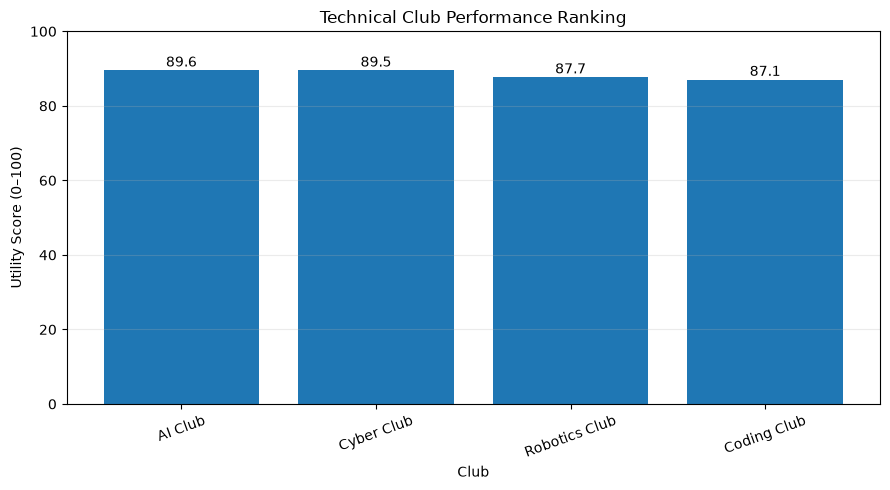

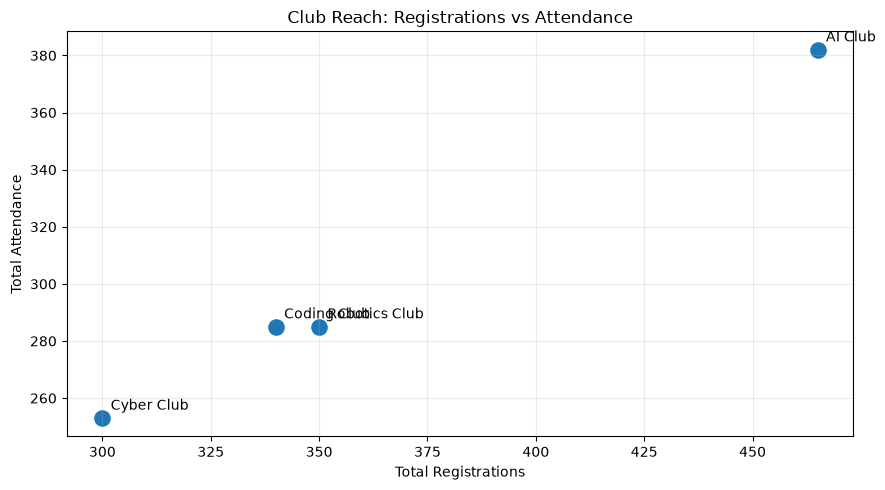

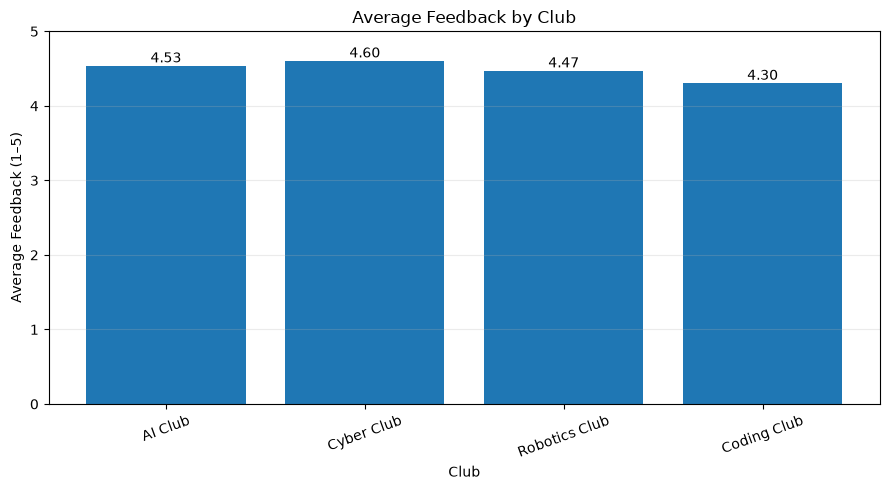

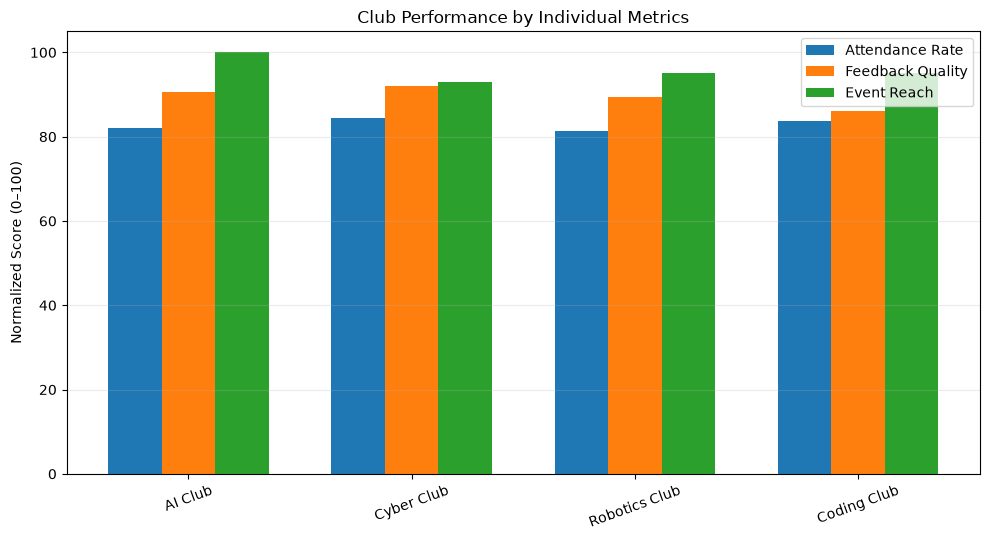

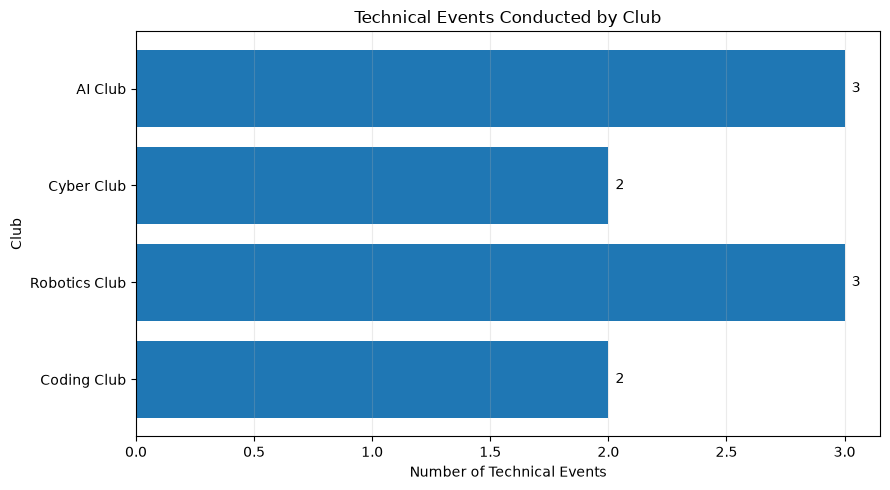

In [11]:
# 11. Visual Analytics Dashboard
# Multiple views make the final agent output easier to interpret.

ranking = agent.state['ranking'].sort_values('utility_score', ascending=False).copy()

# 1) Utility-score ranking
plt.figure(figsize=(9, 5))
bars = plt.bar(ranking['club'], ranking['utility_score'])
plt.ylabel('Utility Score (0–100)')
plt.xlabel('Club')
plt.title('Technical Club Performance Ranking')
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.25)
for bar, value in zip(bars, ranking['utility_score']):
    plt.text(bar.get_x() + bar.get_width()/2, value + 1,
             f'{value:.1f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# 2) Attendance vs registration
plt.figure(figsize=(9, 5))
plt.scatter(ranking['registrations'], ranking['attendance'], s=120)
for _, row in ranking.iterrows():
    plt.annotate(row['club'], (row['registrations'], row['attendance']),
                 xytext=(6, 6), textcoords='offset points')
plt.xlabel('Total Registrations')
plt.ylabel('Total Attendance')
plt.title('Club Reach: Registrations vs Attendance')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 3) Average feedback
plt.figure(figsize=(9, 5))
bars = plt.bar(ranking['club'], ranking['avg_feedback'])
plt.ylabel('Average Feedback (1–5)')
plt.xlabel('Club')
plt.title('Average Feedback by Club')
plt.ylim(0, 5)
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.25)
for bar, value in zip(bars, ranking['avg_feedback']):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.05,
             f'{value:.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# 4) Metric comparison
metric_cols = ['attendance_rate', 'feedback_pct', 'reach_pct']
metric_labels = ['Attendance Rate', 'Feedback Quality', 'Event Reach']

plt.figure(figsize=(10, 5.5))
x = np.arange(len(ranking))
width = 0.24
for j, (col, label) in enumerate(zip(metric_cols, metric_labels)):
    plt.bar(x + (j-1)*width, ranking[col], width, label=label)
plt.xticks(x, ranking['club'], rotation=20)
plt.ylabel('Normalized Score (0–100)')
plt.title('Club Performance by Individual Metrics')
plt.ylim(0, 105)
plt.legend()
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# 5) Event count
plt.figure(figsize=(9, 5))
bars = plt.barh(ranking['club'][::-1], ranking['events'][::-1])
plt.xlabel('Number of Technical Events')
plt.ylabel('Club')
plt.title('Technical Events Conducted by Club')
plt.grid(axis='x', alpha=0.25)
for bar, value in zip(bars, ranking['events'][::-1]):
    plt.text(value + 0.03, bar.get_y() + bar.get_height()/2,
             f'{int(value)}', va='center', fontsize=10)
plt.tight_layout()
plt.show()


In [12]:
# 12. Data-quality check — main dataset is complete

_, issues = handle_missing(events)

print("Missing-data check:")
if issues:
    print("\n".join("• " + x for x in issues))
    print("\nData-quality note: the current semester dataset contains missing observations.")
    print("The agent flags them and does not fabricate values.")
else:
    print("• No missing values found in the current semester dataset.")
    print("• No feedback values were fabricated or imputed.")
    print("• The ranking can be generated from complete observations.")

print("\nDesign rule: missing raw observations are flagged rather than fabricated.")


Missing-data check:
• No missing values detected in the supplied dataset.

Data-quality note: the current semester dataset contains missing observations.
The agent flags them and does not fabricate values.

Design rule: missing raw observations are flagged rather than fabricated.


In [13]:
# Optional: demonstrate how the agent handles missing feedback
# This cell is NOT part of the main ranking and does not change the real output.

missing_demo = events.copy()
missing_demo.loc[2, 'feedback_score'] = np.nan

_, demo_issues = handle_missing(missing_demo)

print("Optional missing-data scenario:")
if demo_issues:
    print("\n".join("• " + x for x in demo_issues))
else:
    print("• No missing values found.")

print("\nAgent response:")
print("1. Flag the missing observation.")
print("2. Do not fabricate a feedback score.")
print("3. Disclose the limitation in the report.")
print("4. If required, request the missing feedback before finalizing a feedback-dependent ranking.")


Optional missing-data scenario:
• feedback_score: 1 missing value(s)

Agent response:
1. Flag the missing observation.
2. Do not fabricate a feedback score.
3. Disclose the limitation in the report.
4. If required, request the missing feedback before finalizing a feedback-dependent ranking.


## 13. Optional LLM report layer

For a real deployment, the deterministic metric engine should remain responsible for arithmetic and ranking. An LLM can be added only for natural-language interpretation and report formatting.

Recommended pattern from the supplied LLM/Agentic AI notes: **LLM for language/reasoning + deterministic tools for precise operations**. The LLM should receive the already-calculated metrics and evidence, not invent numbers.

A production version can connect `TOOLS` to SQL, Google Sheets, REST APIs or institutional databases and use an LLM through function/tool calling.

## 14. Evaluation checklist

| Requirement | Demonstrated |
|---|---|
| Understand reporting request | `understand_goal()` |
| Collect event data | event tool |
| Collect registration data | registration tool |
| Collect attendance data | attendance tool |
| Collect feedback data | feedback tool |
| Calculate metrics | `calculate_metrics()` |
| Compare clubs | `add_utility_score()` |
| Explain rankings | `explain()` |
| Handle missing data | `handle_missing()` |
| Agentic planning/action/observation | controller + trace |
| Visual report | 5 analytical visualizations |

### Viva points
- **Why use an agent?** The task is multi-step and requires tool selection, validation, reasoning and report generation rather than a single prediction.
- **Why deterministic metrics?** Arithmetic and ranking should be reproducible and auditable.
- **Where is utility-based reasoning?** The agent ranks clubs using a weighted utility score balancing feedback, participation and reach.
- **How is uncertainty handled?** Missing observations are detected and disclosed instead of being silently fabricated.
- **How can it scale?** Replace the synthetic DataFrames with database/API tools while keeping the controller and metric engine.